In [1]:
import sys
import os
# %%autoreload 2
# Add current directory to path
sys.path.append('.')

# Import configuration
from config_loader import Config

# Import custom modules
from preprocess_data import load_sentiment140_data, TextPreprocessor
from dataset import AutocompleteDataset
from lstm_model import LSTMAutocomplete
from train_lstm import train_lstm, save_model, load_model
from evaluate_lstm import evaluate_lstm, predict_next_tokens
from evaluate_distilgpt2 import DistilGPT2Autocomplete, create_distilgpt2_test_data
from compare_models import compare_models, analyze_errors

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import json
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Load configuration
config = Config('../config/config.yaml')

# Set random seeds for reproducibility
torch.manual_seed(config.random_seed)
np.random.seed(config.random_seed)

# Check if GPU is available
device = config.device if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Display configuration
print("\nConfiguration:")
print("="*50)
print(f"Data path: {config.data_path}")
print(f"Vocabulary size: {config.max_vocab_size}")
print(f"Sequence length: {config.seq_length}")
print(f"Predict tokens: {config.predict_n_tokens}")
print(f"Embedding dimension: {config.embedding_dim}")
print(f"Hidden dimension: {config.hidden_dim}")
print(f"Number of layers: {config.num_layers}")
print(f"Batch size: {config.batch_size}")
print(f"Number of epochs: {config.num_epochs}")
print(f"Learning rate: {config.learning_rate}")
print("="*50)


/home/msi_g66/Documents/development/ML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda

Configuration:
Data path: ../data/training.100000.processed.noemoticon.csv
Vocabulary size: 10000
Sequence length: 5
Predict tokens: 1
Embedding dimension: 128
Hidden dimension: 512
Number of layers: 3
Batch size: 512
Number of epochs: 5
Learning rate: 0.001


In [2]:
# Load Sentiment140 dataset
print("Loading Sentiment140 dataset...")
data = load_sentiment140_data(config)

if data is None:
    # Create sample data for demonstration if dataset not found
    print("Dataset not found. Creating sample data...")
    # You would need to download the dataset or create sample data here
    # For now, we'll exit
    raise FileNotFoundError(f"Please download the Sentiment140 dataset first and place it at: {config.data_path}")

preprocessor = data['preprocessor']
X_train, y_train = data['X_train'], data['y_train']
X_val, y_val = data['X_val'], data['y_val']

print(f"Vocabulary size: {preprocessor.vocab_size}")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

# Display sample of the data
print("\nSample data:")
print(f"Input sequence (first 10 tokens): {X_train[0][:10]}")
print(f"Target tokens: {y_train[0]}")

# Convert to text for display
sample_input_text = preprocessor.sequences_to_text([X_train[0]])[0]
sample_target_text = preprocessor.sequences_to_text([y_train[0]])[0]
print(f"Input text: ...{sample_input_text}")
print(f"Target text: {sample_target_text}")

# Save preprocessor
preprocessor.save(config.preprocessor_save)
print(f"\nPreprocessor saved to {config.preprocessor_save}")

Loading Sentiment140 dataset...
Vocabulary size: 10004
Training samples: 266525
Validation samples: 29639

Sample data:
Input sequence (first 10 tokens): [0 0 0 0 2]
Target tokens: [4]
Input text: ...
Target text: haha,

Preprocessor saved to preprocessor.pkl


In [3]:
# Create datasets
train_dataset = AutocompleteDataset(X_train, y_train, preprocessor)
val_dataset = AutocompleteDataset(X_val, y_val, preprocessor)

# Create data loaders
train_loader = train_dataset.get_loader(batch_size=config.batch_size, shuffle=True)
val_loader = val_dataset.get_loader(batch_size=config.batch_size, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 521
Val batches: 58


In [4]:
# ## 5. Initialize LSTM Model

# %%
# Update config with vocab size
config.vocab_size = preprocessor.vocab_size

# Initialize LSTM model
model = LSTMAutocomplete(config)

# Print model summary
print("LSTM Model Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Embedding dimension: {config.embedding_dim}")
print(f"Hidden dimension: {config.hidden_dim}")
print(f"Number of layers: {config.num_layers}")
print(f"Bidirectional: {config.bidirectional}")
print(f"Dropout: {config.dropout}")

LSTM Model Architecture:
LSTMAutocomplete(
  (embedding): Embedding(10004, 128, padding_idx=0)
  (lstm): LSTM(128, 512, num_layers=3, batch_first=True, dropout=0.3)
  (output_layers): ModuleList(
    (0): Sequential(
      (0): Dropout(p=0.3, inplace=False)
      (1): Linear(in_features=512, out_features=512, bias=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features=512, out_features=10004, bias=True)
    )
  )
  (dropout_layer): Dropout(p=0.3, inplace=False)
)

Total parameters: 12,192,532
Embedding dimension: 128
Hidden dimension: 512
Number of layers: 3
Bidirectional: False
Dropout: 0.3


In [5]:
# Train the model
print("Starting training...")
trained_model, history = train_lstm(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    preprocessor=preprocessor,
    config=config
)

# Save the trained model
save_model(trained_model, preprocessor, config.model_save)

Starting training...
Training on cuda
Vocabulary size: 10004
Training samples: 266525
Validation samples: 29639


Epoch 1/5 [Val]: 100%|██████████| 58/58 [00:00<00:00, 107.02it/s]



Epoch 1/5:
  Train Loss: 5.8369, Train ROUGE-1 F1: 0.1200
  Val Loss: 5.4166, Val ROUGE-1 F1: 0.1385
  Learning Rate: 0.001000

  Examples (first 5):
    Input: ... (context)
    Predicted: i
    Actual: okay.

    Input: ... (context)
    Predicted: <UNK>
    Actual: for

    Input: ... (context)
    Predicted: <UNK>
    Actual: first

    Input: ... (context)
    Predicted: i
    Actual: i

    Input: ... (context)
    Predicted: wish
    Actual: need



Epoch 2/5 [Val]: 100%|██████████| 58/58 [00:00<00:00, 81.10it/s] 



Epoch 2/5:
  Train Loss: 5.4021, Train ROUGE-1 F1: 0.1398
  Val Loss: 5.1951, Val ROUGE-1 F1: 0.1491
  Learning Rate: 0.001000

  Examples (first 5):
    Input: ... (context)
    Predicted: <UNK>
    Actual: okay.

    Input: ... (context)
    Predicted: <UNK>
    Actual: for

    Input: ... (context)
    Predicted: <UNK>
    Actual: first

    Input: ... (context)
    Predicted: <UNK>
    Actual: i

    Input: ... (context)
    Predicted: dont
    Actual: need



...


Epoch 3/5:
  Train Loss: 5.2002, Train ROUGE-1 F1: 0.1489
  Val Loss: 5.0387, Val ROUGE-1 F1: 0.1641
  Learning Rate: 0.001000

  Examples (first 5):
    Input: ... (context)
    Predicted: <UNK>
    Actual: okay.

    Input: ... (context)
    Predicted: <UNK>
    Actual: for

    Input: ... (context)
    Predicted: <UNK>
    Actual: first

    Input: ... (context)
    Predicted: <UNK>
    Actual: i

    Input: ... (context)
    Predicted: have
    Actual: need



Epoch 4/5 [Val]: 100%|██████████| 58/58 [00:00<00:00, 83.19it/s] 



Epoch 4/5:
  Train Loss: 5.0661, Train ROUGE-1 F1: 0.1580
  Val Loss: 4.9493, Val ROUGE-1 F1: 0.1694
  Learning Rate: 0.001000

  Examples (first 5):
    Input: ... (context)
    Predicted: <UNK>
    Actual: okay.

    Input: ... (context)
    Predicted: <UNK>
    Actual: for

    Input: ... (context)
    Predicted: the
    Actual: first

    Input: ... (context)
    Predicted: <UNK>
    Actual: i

    Input: ... (context)
    Predicted: wish
    Actual: need



Epoch 5/5 [Val]: 100%|██████████| 58/58 [00:00<00:00, 105.15it/s]



Epoch 5/5:
  Train Loss: 4.9741, Train ROUGE-1 F1: 0.1639
  Val Loss: 4.9018, Val ROUGE-1 F1: 0.1749
  Learning Rate: 0.001000

  Examples (first 5):
    Input: ... (context)
    Predicted: i
    Actual: okay.

    Input: ... (context)
    Predicted: i
    Actual: for

    Input: ... (context)
    Predicted: <UNK>
    Actual: first

    Input: ... (context)
    Predicted: i
    Actual: i

    Input: ... (context)
    Predicted: am
    Actual: need

Model saved to ../model/lstm_autocomplete.pth


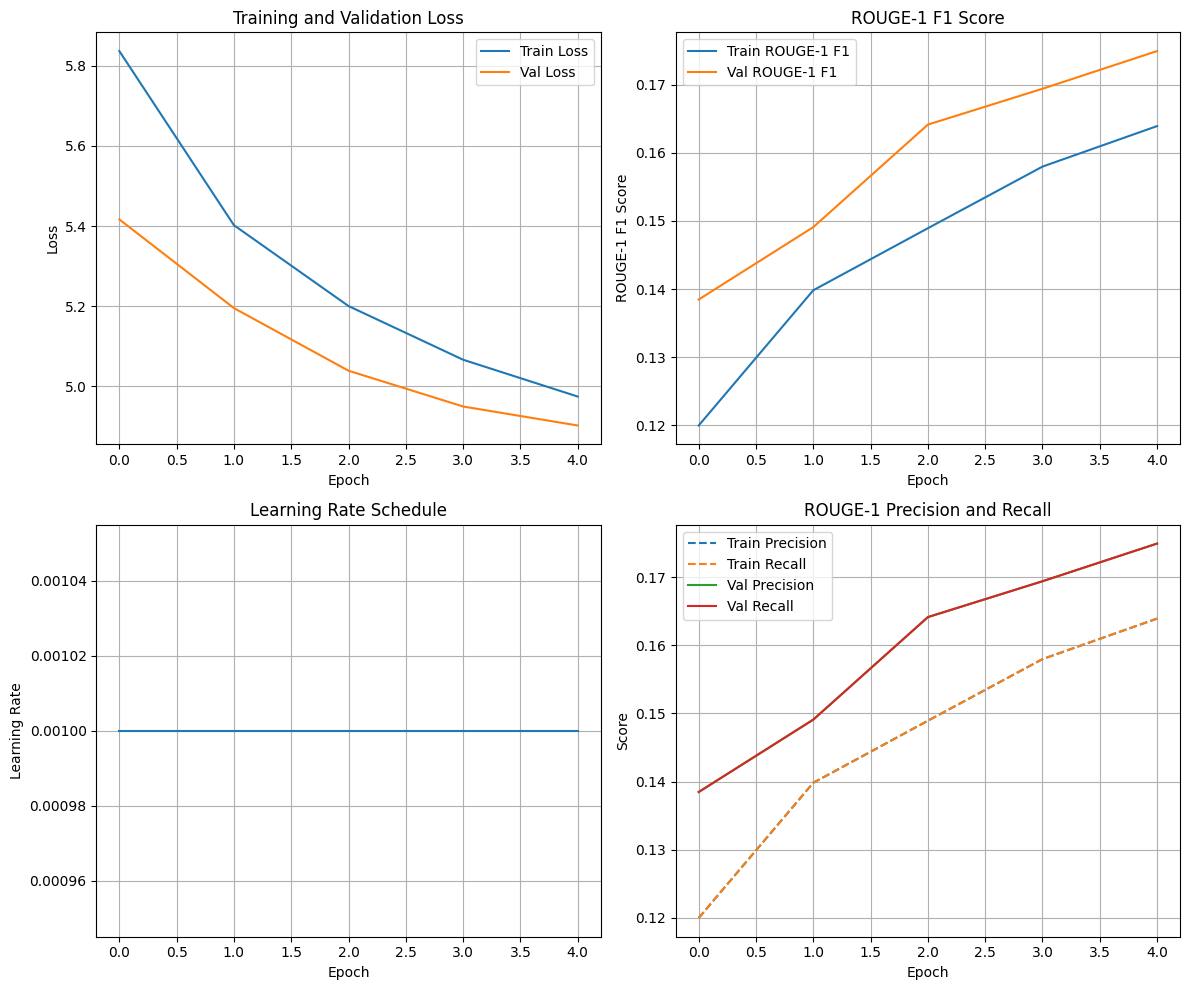

In [6]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Plot ROUGE-1 F1
train_f1 = [r['f1'] for r in history['train_rouge']]
val_f1 = [r['f1'] for r in history['val_rouge']]
axes[0, 1].plot(train_f1, label='Train ROUGE-1 F1')
axes[0, 1].plot(val_f1, label='Val ROUGE-1 F1')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('ROUGE-1 F1 Score')
axes[0, 1].set_title('ROUGE-1 F1 Score')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Plot learning rate
axes[1, 0].plot(history['learning_rate'])
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].grid(True)

# Plot ROUGE-1 Precision and Recall
train_precision = [r['precision'] for r in history['train_rouge']]
train_recall = [r['recall'] for r in history['train_rouge']]
val_precision = [r['precision'] for r in history['val_rouge']]
val_recall = [r['recall'] for r in history['val_rouge']]

axes[1, 1].plot(train_precision, label='Train Precision', linestyle='--')
axes[1, 1].plot(train_recall, label='Train Recall', linestyle='--')
axes[1, 1].plot(val_precision, label='Val Precision')
axes[1, 1].plot(val_recall, label='Val Recall')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('ROUGE-1 Precision and Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(config.training_plot, dpi=100, bbox_inches='tight')
plt.show()

In [7]:
# Evaluate the trained LSTM model
print("Evaluating LSTM model...")
lstm_results = evaluate_lstm(
    model=trained_model,
    dataloader=val_loader,
    preprocessor=preprocessor,
    config=config
)

# Test some predictions
print(f"\nTesting LSTM predictions (first {config.interactive_test_samples}):")
test_inputs = [
    "They call more than",
    "Made me want to go",
    "I really love this",
    "The weather is so",
    "This movie was absolutely",
    "I can't believe how",
    "The service at the restaurant was"
]

for test_input in test_inputs[:config.interactive_test_samples]:
    predict_next_tokens(trained_model, preprocessor, test_input, config)

Evaluating LSTM model...


Evaluating LSTM: 100%|██████████| 58/58 [00:00<00:00, 105.11it/s]


LSTM MODEL EVALUATION
Average Loss: 4.9018
Perplexity: 134.5384
ROUGE-1 Precision: 0.1749
ROUGE-1 Recall: 0.1749
ROUGE-1 F1: 0.1749

Examples (first 5):
--------------------------------------------------
Example 1:
  Predicted: i
  Actual: okay.

Example 2:
  Predicted: i
  Actual: for

Example 3:
  Predicted: <UNK>
  Actual: first

Example 4:
  Predicted: i
  Actual: i

Example 5:
  Predicted: am
  Actual: need


Testing LSTM predictions (first 5):
Input: They call more than
Predicted next 1 tokens: <UNK>
Input: Made me want to go
Predicted next 1 tokens: to
Input: I really love this
Predicted next 1 tokens: <UNK>
Input: The weather is so
Predicted next 1 tokens: <UNK>
Input: This movie was absolutely
Predicted next 1 tokens: <UNK>


In [8]:
# Initialize DistilGPT2
print("Initializing DistilGPT2...")
gpt2_model = DistilGPT2Autocomplete(config)

# Test DistilGPT2 predictions
print(f"\nTesting DistilGPT2 predictions (first {config.interactive_test_samples}):")
for test_input in test_inputs[:config.interactive_test_samples]:
    predicted = gpt2_model.predict_next_tokens(test_input)
    print(f"Input: {test_input}")
    print(f"Predicted: {' '.join(predicted)}")
    print()

# Prepare test data for evaluation
print(f"Preparing test data for DistilGPT2 evaluation ({config.num_samples_gpt2_eval} samples)...")
test_texts, test_references = create_distilgpt2_test_data(
    preprocessor, 
    data['val_texts'], 
    config
)

# Evaluate DistilGPT2
print(f"\nEvaluating DistilGPT2 on {len(test_texts)} samples...")
gpt2_results = gpt2_model.evaluate_on_dataset(
    texts=test_texts,
    references=test_references
)

Device set to use cuda:0


Initializing DistilGPT2...

Testing DistilGPT2 predictions (first 5):


Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Both `max_new_tokens` (=256) and `max_length`(=5) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=6) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generatio

Input: They call more than
Predicted: a



Both `max_new_tokens` (=256) and `max_length`(=5) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Input: I really love this
Predicted: game.



Both `max_new_tokens` (=256) and `max_length`(=5) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Input: The weather is so
Predicted: bad

Input: This movie was absolutely
Predicted: amazing.

Preparing test data for DistilGPT2 evaluation (10 samples)...

Evaluating DistilGPT2 on 10 samples...
Evaluating distilgpt2 on 10 samples...


  0%|          | 0/1 [00:00<?, ?it/s]Both `max_new_tokens` (=256) and `max_length`(=11) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=6) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=7) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=8) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/


DISTILGPT2 EVALUATION
ROUGE-1 Precision: 0.0000
ROUGE-1 Recall: 0.0000
ROUGE-1 F1: 0.0000

Examples (first 5):
--------------------------------------------------
Example 1:
  Context: ... first day, am very very
  Predicted: happy.
  Actual: tired

Example 2:
  Context: ... i need a cuddle
  Predicted: .
  Actual: buddy

Example 3:
  Context: ... nope urgh im so
  Predicted: i
  Actual: sick

Example 4:
  Context: ... we simply cant have it
  Predicted: .
  Actual: all

Example 5:
  Context: ... of grammar, and two tests
  Predicted: .
  Actual: t___t



In [9]:
torch.cuda.empty_cache()